# 200 - BCK_44 scRNA-seq NB K-Sweep (K = 4-8)

Objective:
- Load 10x `filtered_feature_bc_matrix.h5` from BCK_44 (non-PDX).
- Perform lenient QC following notebook 9.2 (mt/ribo filters + optional scrublet).
- Select HVGs after log1p normalization.
- Save processed HVG counts to H5AD.
- Run probabilistic archetypal autoencoder (NB decoder) for `K in [4,5,6,7,8]`.
- Recommend best K using diagnostics similar to notebook 13.



In [1]:
from pathlib import Path
import sys


def _find_repo_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for path in candidates:
        if (path / 'pyproject.toml').exists() and (path / 'src' / 'cytof_archetypes').exists():
            return path
    fallback = Path('/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv')
    if (fallback / 'src' / 'cytof_archetypes').exists():
        return fallback
    raise RuntimeError('Could not locate repository root')


REPO_ROOT = _find_repo_root()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

print('Repo root:', REPO_ROOT)



Repo root: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv


## Step 1 - Load Config and Define Paths

This notebook is driven by `configs/bck44_scrna_nb_k_sweep.yaml`.



In [2]:
import copy
import os
import json
import yaml
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
import matplotlib.pyplot as plt

from cytof_archetypes.config import load_config
from cytof_archetypes.training import train_from_config

CONFIG_PATH = REPO_ROOT / 'configs' / 'bck44_scrna_nb_k_sweep.yaml'
assert CONFIG_PATH.exists(), f'Missing config: {CONFIG_PATH}'


with CONFIG_PATH.open('r', encoding='utf-8') as f:
    nb_cfg = yaml.safe_load(f)


def _resolve_path(p: str | None) -> Path | None:
    if p is None:
        return None
    path = Path(p).expanduser()
    if not path.is_absolute():
        path = REPO_ROOT / path
    return path


TENX_H5 = _resolve_path(nb_cfg['raw_data']['tenx_h5'])
PROCESSED_H5AD = _resolve_path(nb_cfg['processed_data']['output_h5ad'])
SWEEP_OUTPUT_ROOT = _resolve_path(nb_cfg['output']['base_dir']).parent
SWEEP_RUNS_DIR = _resolve_path(nb_cfg['output']['base_dir'])

print('Config path      :', CONFIG_PATH)
print('10x h5 path      :', TENX_H5)
print('Processed H5AD   :', PROCESSED_H5AD)
print('Sweep output root:', SWEEP_OUTPUT_ROOT)
print('Sweep runs dir   :', SWEEP_RUNS_DIR)




Config path      : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/configs/bck44_scrna_nb_k_sweep.yaml
10x h5 path      : /Users/ronguy/Dropbox/Work/CyTOF/SingleCell/MOme_MPGMP/MultiOme/Data/BCK_44/filtered_feature_bc_matrix.h5
Processed H5AD   : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/bck44_scrna_hvg_counts.h5ad
Sweep output root: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/bck44_scrna_nb_k_sweep
Sweep runs dir   : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/bck44_scrna_nb_k_sweep/runs


## Step 2 - Load 10x Data, Lenient QC, Log1p, HVGs, Save Processed H5AD

Notes:
- Non-PDX sample (BCK_44): no mouse/human species filtering is applied.
- QC mirrors notebook 9.2 style: mt/ribo thresholds, optional scrublet filtering.
- HVG selection is performed on log1p-normalized expression.
- Saved `X` is raw HVG counts (for NB decoder target).
- `cell_id` is preserved in `.obs`.



In [3]:
# ---- Toggle ----
FORCE_REGENERATE_PROCESSED = True

# ---- Config ----
qc_cfg = nb_cfg.get('qc', {})
hvg_cfg = nb_cfg.get('hvg', {})

# 9.2-like lenient thresholds
MIN_GENES_PER_CELL = int(qc_cfg.get('min_genes_per_cell', 200))
MAX_GENES_PER_CELL = int(qc_cfg.get('max_genes_per_cell', 9000))
MAX_COUNTS_PER_CELL = int(qc_cfg.get('max_counts_per_cell', 80000))
MAX_PCT_MT = float(qc_cfg.get('max_pct_mt', 35.0))
MAX_PCT_RIBO = float(qc_cfg.get('max_pct_ribo', 65.0))
MIN_CELLS_PER_GENE = int(qc_cfg.get('min_cells_per_gene', 3))
MIN_COUNTS_PER_CELL = int(qc_cfg.get('min_counts_per_cell', 500))

RUN_DOUBLET_SCORING = bool(qc_cfg.get('run_doublet_scoring', True))
FILTER_STRONG_DOUBLET = bool(qc_cfg.get('filter_strong_doublet', True))
DOUBLET_SCORE_MAX = float(qc_cfg.get('doublet_score_max', 0.35))

# keep as optional because in 9.2 they were intentionally lenient
APPLY_MINMAX_QC = bool(qc_cfg.get('apply_minmax_qc', False))

N_TOP_HVG = int(hvg_cfg.get('n_top_genes', 2000))
HVG_FLAVOR = str(hvg_cfg.get('flavor', 'seurat'))
HVG_SPAN = hvg_cfg.get('span', None)

assert TENX_H5.exists(), f'10x h5 file not found: {TENX_H5}'
PROCESSED_H5AD.parent.mkdir(parents=True, exist_ok=True)

if PROCESSED_H5AD.exists() and not FORCE_REGENERATE_PROCESSED:
    print(f'Using existing processed H5AD: {PROCESSED_H5AD}')
    adata_hvg_counts = sc.read_h5ad(PROCESSED_H5AD)
else:
    print('Reading 10x h5 matrix...')
    adata = sc.read_10x_h5(TENX_H5)
    adata.var_names_make_unique()
    adata.obs_names_make_unique()
    adata.obs['cell_id'] = adata.obs_names.astype(str)

    # Keep raw counts for NB target and scrublet input
    adata.layers['counts'] = adata.X.copy()

    # 9.2-style QC feature annotations
    adata.var['mt'] = adata.var_names.str.upper().str.startswith(('MT-', 'MT.'))
    adata.var['ribo'] = adata.var_names.str.upper().str.startswith(('RPS', 'RPL'))
    adata.var['hb'] = adata.var_names.str.upper().str.match(r'^HB[ABDGEMQZ]')

    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=['mt', 'ribo', 'hb'],
        inplace=True,
        percent_top=(20, 50),
    )

    qc_keep = (
        (adata.obs['pct_counts_mt'] <= MAX_PCT_MT)
        & (adata.obs['pct_counts_ribo'] <= MAX_PCT_RIBO)
    )

    if APPLY_MINMAX_QC:
        qc_keep = (
            qc_keep
            & (adata.obs['n_genes_by_counts'] >= MIN_GENES_PER_CELL)
            & (adata.obs['n_genes_by_counts'] <= MAX_GENES_PER_CELL)
            & (adata.obs['total_counts'] >= MIN_COUNTS_PER_CELL)
            & (adata.obs['total_counts'] <= MAX_COUNTS_PER_CELL)
        )

    adata.obs['qc_keep'] = qc_keep
    print('QC keep rate:', round(float(qc_keep.mean()), 3), f'({int(qc_keep.sum())}/{len(qc_keep)})')
    adata = adata[qc_keep].copy()

    # Keep genes with at least minimal support
    sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)

    # Optional scrublet pass (same spirit as 9.2)
    if RUN_DOUBLET_SCORING:
        try:
            sc.pp.scrublet(adata, batch_key=None)
            if 'doublet_score' in adata.obs.columns:
                adata.obs['is_strong_doublet'] = adata.obs['doublet_score'] > DOUBLET_SCORE_MAX
                print('Strong doublet rate:', round(float(adata.obs['is_strong_doublet'].mean()), 3))
            else:
                adata.obs['is_strong_doublet'] = False
                print('Scrublet ran but doublet_score missing; no filtering applied.')
        except Exception as e:
            adata.obs['is_strong_doublet'] = False
            print('Doublet scoring skipped due to error:', e)
    else:
        adata.obs['is_strong_doublet'] = False

    if FILTER_STRONG_DOUBLET:
        before = int(adata.n_obs)
        adata = adata[~adata.obs['is_strong_doublet']].copy()
        print(f'Filtered strong doublets: {before - adata.n_obs} cells removed; {adata.n_obs} remain')

    # extra floor on very low-depth cells
    adata = adata[adata.obs['total_counts'] >= MIN_COUNTS_PER_CELL].copy()

    n1, g1 = adata.n_obs, adata.n_vars
    print(f'After QC : cells={n1:,}, genes={g1:,}')

    # Log1p normalization for HVG selection
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    hvg_kwargs = dict(n_top_genes=N_TOP_HVG, flavor=HVG_FLAVOR)
    if HVG_SPAN is not None:
        hvg_kwargs['span'] = float(HVG_SPAN)

    try:
        sc.pp.highly_variable_genes(adata, **hvg_kwargs)
    except TypeError:
        # some flavor/version combos do not support span
        hvg_kwargs.pop('span', None)
        sc.pp.highly_variable_genes(adata, **hvg_kwargs)

    hvg_mask = adata.var['highly_variable'].to_numpy()
    adata_hvg = adata[:, hvg_mask].copy()
    adata_hvg.layers['log1p_norm'] = adata_hvg.X.copy()

    # For NB training: X should be raw counts
    adata_hvg.X = adata_hvg.layers['counts'].copy()

    # Ensure numeric dtype and cell_id column
    if sparse.issparse(adata_hvg.X):
        adata_hvg.X = adata_hvg.X.tocsr().astype(np.float32)
    else:
        adata_hvg.X = np.asarray(adata_hvg.X, dtype=np.float32)

    adata_hvg.obs['cell_id'] = adata_hvg.obs['cell_id'].astype(str)

    adata_hvg_counts = adata_hvg
    adata_hvg_counts.write_h5ad(PROCESSED_H5AD)
    print(f'Wrote processed HVG-count H5AD: {PROCESSED_H5AD}')

print('Final training matrix shape:', adata_hvg_counts.shape)
print('Nonzero fraction:', float((adata_hvg_counts.X != 0).sum() / (adata_hvg_counts.n_obs * adata_hvg_counts.n_vars)))




Reading 10x h5 matrix...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


QC keep rate: 0.905 (363/401)
Strong doublet rate: 0.0
Filtered strong doublets: 0 cells removed; 363 remain
After QC : cells=352, genes=20,261
Wrote processed HVG-count H5AD: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/bck44_scrna_hvg_counts.h5ad
Final training matrix shape: (352, 2000)
Nonzero fraction: 0.12348011363636363


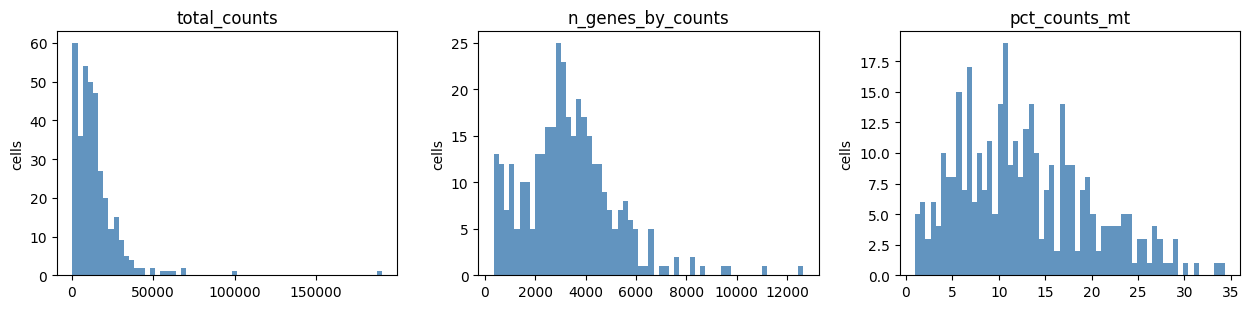

In [4]:
# Optional quick QC visuals from processed object metadata
# (If loaded from existing H5AD without QC columns, this may be skipped.)
plot_cols = [c for c in ['total_counts', 'n_genes_by_counts', 'pct_counts_mt'] if c in adata_hvg_counts.obs.columns]
if len(plot_cols) > 0:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(4.2 * len(plot_cols), 3.2))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        vals = pd.to_numeric(adata_hvg_counts.obs[col], errors='coerce').to_numpy()
        vals = vals[np.isfinite(vals)]
        ax.hist(vals, bins=60, color='steelblue', alpha=0.85)
        ax.set_title(col)
        ax.set_ylabel('cells')
    plt.tight_layout()
    plt.show()
else:
    print('QC columns not found in .obs; skipping QC plots.')



## Step 3 — Run NB Probabilistic AE K-Sweep

By default, sweep reuses completed runs and skips existing run directories.



In [5]:
from datetime import datetime

RUN_SWEEP = True      # set True to execute training sweep
FORCE_RERUN = True    # if True, reruns even if run dir already exists

base_train_cfg = load_config(CONFIG_PATH)
base_train_cfg = copy.deepcopy(base_train_cfg)

# Ensure processed dataset path is used
base_train_cfg['dataset']['input_path'] = str(PROCESSED_H5AD)
base_train_cfg['output']['base_dir'] = str(SWEEP_RUNS_DIR)

k_values = [int(k) for k in nb_cfg.get('sweep', {}).get('k_values', [4, 5, 6, 7, 8])]
seeds = [int(s) for s in nb_cfg.get('sweep', {}).get('seeds', [42, 123, 456])]

SWEEP_RUNS_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print('K values:', k_values)
print('Seeds   :', seeds)
print('Runs dir:', SWEEP_RUNS_DIR)

run_manifest_rows = []
for k in k_values:
    for sd in seeds:
        run_name = f'k{k}_seed{sd}'
        run_dir = SWEEP_RUNS_DIR / run_name
        status = 'pending'
        t_start = datetime.now().isoformat(timespec='seconds')

        if run_dir.exists() and not FORCE_RERUN:
            status = 'skipped_existing'
            print(f'[skip] {run_name}')
        elif RUN_SWEEP:
            cfg_run = copy.deepcopy(base_train_cfg)
            cfg_run['seed'] = int(sd)
            cfg_run['model']['n_archetypes'] = int(k)
            cfg_run['output']['run_name'] = run_name
            cfg_run['training']['progress_bar'] = True
            cfg_run['training']['progress_bar_leave'] = False
            cfg_run['training']['progress_bar_desc'] = 'bck44-nb'
            print(f'[run ] {run_name}')
            out_dir = train_from_config(cfg_run)
            run_dir = Path(out_dir)
            status = 'completed'
        else:
            status = 'not_run'

        run_manifest_rows.append(
            {
                'k': int(k),
                'seed': int(sd),
                'run_name': run_name,
                'run_dir': str(run_dir),
                'status': status,
                'timestamp': t_start,
            }
        )

manifest_df = pd.DataFrame(run_manifest_rows)
manifest_path = SWEEP_OUTPUT_ROOT / 'sweep_manifest.csv'
manifest_df.to_csv(manifest_path, index=False)
print('Manifest:', manifest_path)
display(manifest_df)




[2026-04-09 09:25:29] INFO cytof_archetypes - Run directory: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/bck44_scrna_nb_k_sweep/runs/k4_seed42
[2026-04-09 09:25:29] INFO cytof_archetypes - model decoder_family=nb total_params=1100692 trainable_params=1100692 frozen_params=0


K values: [4, 5, 6, 7, 8]
Seeds   : [42]
Runs dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/bck44_scrna_nb_k_sweep/runs
[run ] k4_seed42

=== Model Architecture ===
ProbabilisticArchetypalAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=2000, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=4, bias=True)
  )
)

=== Model Parameters ===
decoder_family: nb
total_params: 1,100,692
trainable_params: 1,100,692
frozen_params: 0
parameter_tensors:
  - archetype_logits: shape=(4, 2000), count=8,000, requires_grad=True
  - log_theta: shape=(2000,), count=2,000, requires_grad=True
  - encoder.0.weight: shape=(512, 2000), count=1,024,000, requires_grad=True
  - encoder.0.bias: shape=(512,), count=512, requires_grad=True
  - encoder.3.weight: shape=(128, 512), 

bck44-nb [k4_seed42]:   0%|          | 0/5000 [00:00<?, ?epoch/s]

[umap] fitting on all 53 points ...
UMAP(min_dist=0.15, n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Thu Apr  9 09:25:52 2026 Construct fuzzy simplicial set
Thu Apr  9 09:25:52 2026 Finding Nearest Neighbors


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu Apr  9 09:27:17 2026 Finished embedding
[umap] transforming 53 points in 1 chunk(s) of 100,000 ...
[umap]   chunk 1/1: rows 0–53
[umap] done. Output shape: (53, 2)
[umap] fitting on all 53 points ...
UMAP(min_dist=0.15, n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Thu Apr  9 09:27:17 2026 Construct fuzzy simplicial set
Thu Apr  9 09:27:17 2026 Finding Nearest Neighbors
Thu Apr  9 09:27:17 2026 Finished Nearest Neighbor Search
Thu Apr  9 09:27:17 2026 Construct embedding


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu Apr  9 09:27:17 2026 Finished embedding
[umap] transforming 53 points in 1 chunk(s) of 100,000 ...
[umap]   chunk 1/1: rows 0–53
[umap] done. Output shape: (53, 2)
Manifest: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/bck44_scrna_nb_k_sweep/sweep_manifest.csv


,k,seed,run_name,run_dir,status,timestamp
0,4,42,k4_seed42,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...,completed,2026-04-09T09:25:29
1,5,42,k5_seed42,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...,completed,2026-04-09T09:25:55
2,6,42,k6_seed42,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...,completed,2026-04-09T09:26:20
3,7,42,k7_seed42,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...,completed,2026-04-09T09:26:40
4,8,42,k8_seed42,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...,completed,2026-04-09T09:26:57


## Step 4 — Load Sweep Outputs and Compute Per-Run Metrics

Metrics parallel notebook 13, adapted for NB decoder:
- `best_val_recon` (lower is better)
- active archetype fraction (based on mean weight usage)
- effective K
- diversity (pairwise L2 of archetype gene fractions)
- assignment concentration



In [6]:
from itertools import combinations
from scipy.optimize import linear_sum_assignment

ASSIGN_THRESH = 0.25
ACTIVE_USAGE_FACTOR = 0.50  # active if mean weight >= ACTIVE_USAGE_FACTOR / K


def _safe_read_json(path: Path) -> dict:
    if not path.exists():
        return {}
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def _read_weights(run_dir: Path) -> np.ndarray | None:
    for name in ['cell_weights_val.csv', 'cell_weights_test.csv', 'cell_weights_train.csv']:
        p = run_dir / 'weights' / name
        if p.exists():
            wdf = pd.read_csv(p)
            cols = [c for c in wdf.columns if c.startswith('w_')]
            if len(cols) > 0:
                return wdf[cols].to_numpy(dtype=np.float32)
    return None


def _read_archetype_fractions(run_dir: Path) -> pd.DataFrame | None:
    p = run_dir / 'archetypes' / 'archetype_gene_fractions.csv'
    if not p.exists():
        return None
    return pd.read_csv(p, index_col=0)


def _load_run(k: int, seed: int) -> dict | None:
    run_dir = SWEEP_RUNS_DIR / f'k{k}_seed{seed}'
    if not run_dir.exists():
        return None

    hist_path = run_dir / 'training_log.csv'
    frac_df = _read_archetype_fractions(run_dir)
    W = _read_weights(run_dir)

    if (not hist_path.exists()) or (frac_df is None) or (W is None):
        return None

    hist = pd.read_csv(hist_path)
    metrics_val = _safe_read_json(run_dir / 'metrics' / 'val_metrics.json')

    return {
        'k': int(k),
        'seed': int(seed),
        'run_dir': run_dir,
        'hist': hist,
        'fractions': frac_df,
        'W': W,
        'metrics_val': metrics_val,
    }


def _run_metrics(run: dict) -> dict:
    k = run['k']
    hist = run['hist']
    W = run['W']
    F = run['fractions'].to_numpy(dtype=np.float32)

    if 'val_recon' in hist.columns:
        best_val_recon = float(hist['val_recon'].min())
    elif 'val_nll' in hist.columns:
        best_val_recon = float(hist['val_nll'].min())
    else:
        best_val_recon = float(hist['val_loss'].min())

    n_epochs = int(len(hist))

    W_safe = np.clip(W, 1e-9, 1.0)
    entropy = -(W_safe * np.log(W_safe)).sum(axis=1)
    effective_k = float(np.exp(entropy.mean()))
    assign_frac = float((W.max(axis=1) >= ASSIGN_THRESH).mean())

    usage = W.mean(axis=0)
    usage_thresh = ACTIVE_USAGE_FACTOR / float(k)
    n_active = int((usage >= usage_thresh).sum())
    active_frac = float(n_active / float(k))

    if F.shape[0] > 1:
        dvals = [np.linalg.norm(F[i] - F[j]) for i, j in combinations(range(F.shape[0]), 2)]
        diversity = float(np.mean(dvals))
    else:
        diversity = 0.0

    return {
        'k': int(k),
        'seed': int(run['seed']),
        'best_val_recon': best_val_recon,
        'n_epochs': n_epochs,
        'n_active': n_active,
        'active_frac': active_frac,
        'effective_k': effective_k,
        'effective_k_frac': float(effective_k / float(k)),
        'diversity': diversity,
        'assign_frac': assign_frac,
        'mean_entropy': float(entropy.mean()),
    }


def _cross_seed_stability(runs_k: list[dict]) -> float:
    if len(runs_k) < 2:
        return float('nan')
    sims = []
    for r1, r2 in combinations(runs_k, 2):
        A = r1['fractions'].to_numpy(dtype=np.float32)
        B = r2['fractions'].to_numpy(dtype=np.float32)

        A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-9)
        B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-9)
        C = A @ B.T
        ri, ci = linear_sum_assignment(1.0 - C)
        sims.append(float(C[ri, ci].mean()))
    return float(np.mean(sims))


all_runs = {}
rows = []
for k in k_values:
    runs_k = []
    for sd in seeds:
        run = _load_run(k, sd)
        if run is None:
            continue
        runs_k.append(run)
        rows.append(_run_metrics(run))
    all_runs[k] = runs_k
    print(f'K={k}: loaded {len(runs_k)} run(s)')

metrics_df = pd.DataFrame(rows)
if len(metrics_df) == 0:
    raise RuntimeError('No completed runs found. Set RUN_SWEEP=True (Step 3) or check run directories.')

print('\\nPer-run metrics:')
display(metrics_df.sort_values(['k', 'seed']).round(4))



K=4: loaded 1 run(s)
K=5: loaded 1 run(s)
K=6: loaded 1 run(s)
K=7: loaded 1 run(s)
K=8: loaded 1 run(s)
\nPer-run metrics:


,k,seed,best_val_recon,n_epochs,n_active,active_frac,effective_k,effective_k_frac,diversity,assign_frac,mean_entropy
0,4,42,1005.7595,750,1,0.2500,1.3268,0.3317,0.1211,1.0,0.2828
1,5,42,1033.8684,877,1,0.2000,1.0000,0.2000,0.0701,1.0,0.0000
2,6,42,1005.4136,788,2,0.3333,1.6610,0.2768,0.1447,1.0,0.5074
3,7,42,1014.1567,595,4,0.5714,1.8523,0.2646,0.1220,1.0,0.6164
4,8,42,1003.9905,721,2,0.2500,1.4778,0.1847,0.1541,1.0,0.3905


In [7]:
stability_df = pd.DataFrame(
    [{'k': k, 'cross_seed_stability': _cross_seed_stability(runs)} for k, runs in all_runs.items()]
)

agg = (
    metrics_df.groupby('k', as_index=False)
    .agg(
        best_val_recon_mean=('best_val_recon', 'mean'),
        best_val_recon_std=('best_val_recon', 'std'),
        active_frac_mean=('active_frac', 'mean'),
        effective_k_mean=('effective_k', 'mean'),
        effective_k_frac_mean=('effective_k_frac', 'mean'),
        diversity_mean=('diversity', 'mean'),
        assign_frac_mean=('assign_frac', 'mean'),
        n_seeds=('seed', 'count'),
    )
    .merge(stability_df, on='k', how='left')
)

summary_path = SWEEP_OUTPUT_ROOT / 'k_sweep_summary.csv'
agg.to_csv(summary_path, index=False)
print('Saved summary:', summary_path)
print('Per-K summary:')
display(agg.round(4))



Saved summary: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/bck44_scrna_nb_k_sweep/k_sweep_summary.csv
Per-K summary:


,k,best_val_recon_mean,best_val_recon_std,active_frac_mean,effective_k_mean,effective_k_frac_mean,diversity_mean,assign_frac_mean,n_seeds,cross_seed_stability
0,4,1005.7595,NaN,0.2500,1.3268,0.3317,0.1211,1.0,1,NaN
1,5,1033.8684,NaN,0.2000,1.0000,0.2000,0.0701,1.0,1,NaN
2,6,1005.4136,NaN,0.3333,1.6610,0.2768,0.1447,1.0,1,NaN
3,7,1014.1567,NaN,0.5714,1.8523,0.2646,0.1220,1.0,1,NaN
4,8,1003.9905,NaN,0.2500,1.4778,0.1847,0.1541,1.0,1,NaN


## Step 5 — Diagnostic Plots



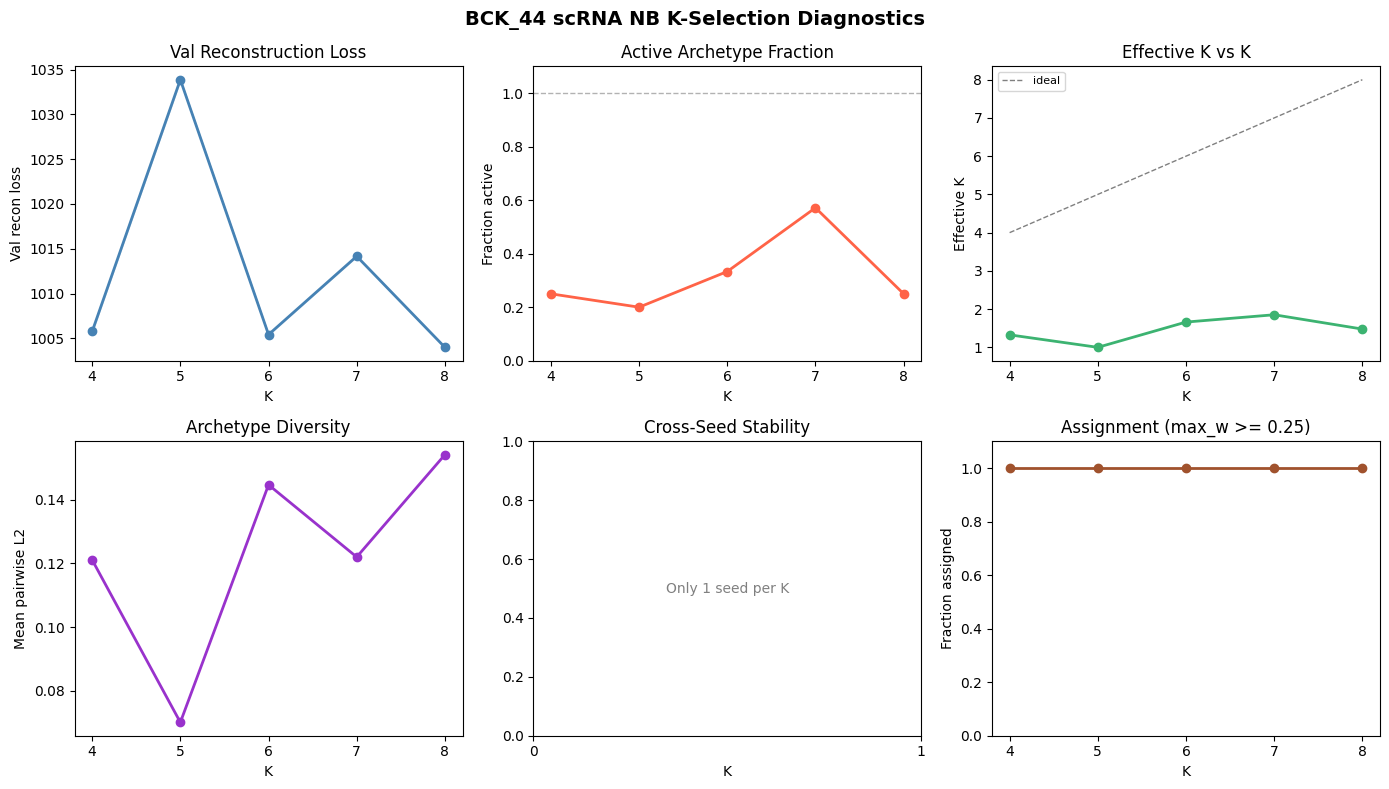

In [8]:
import matplotlib.ticker as mticker

ks = agg['k'].to_numpy()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('BCK_44 scRNA NB K-Selection Diagnostics', fontsize=14, fontweight='bold')


def _plot(ax, col, col_std=None, color='steelblue', ylabel='', title=''):
    y = agg[col].to_numpy()
    ax.plot(ks, y, 'o-', color=color, linewidth=2, markersize=6)
    if col_std is not None and col_std in agg.columns:
        e = agg[col_std].fillna(0).to_numpy()
        ax.fill_between(ks, y - e, y + e, color=color, alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel('K')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))


_plot(axes[0, 0], 'best_val_recon_mean', 'best_val_recon_std', 'steelblue', 'Val recon loss', 'Val Reconstruction Loss')
_plot(axes[0, 1], 'active_frac_mean', color='tomato', ylabel='Fraction active', title='Active Archetype Fraction')
axes[0, 1].axhline(1.0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[0, 1].set_ylim(0, 1.1)

axes[0, 2].plot(ks, ks, '--', color='gray', linewidth=1, label='ideal')
_plot(axes[0, 2], 'effective_k_mean', color='mediumseagreen', ylabel='Effective K', title='Effective K vs K')
axes[0, 2].legend(fontsize=8)

_plot(axes[1, 0], 'diversity_mean', color='darkorchid', ylabel='Mean pairwise L2', title='Archetype Diversity')

ax = axes[1, 1]
if agg['cross_seed_stability'].notna().any():
    ax.plot(ks, agg['cross_seed_stability'].to_numpy(), 'o-', color='darkorange', linewidth=2, markersize=6)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Mean cosine similarity')
else:
    ax.text(0.5, 0.5, 'Only 1 seed per K', ha='center', va='center', transform=ax.transAxes, fontsize=10, color='gray')
ax.set_title('Cross-Seed Stability')
ax.set_xlabel('K')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

_plot(axes[1, 2], 'assign_frac_mean', color='sienna', ylabel='Fraction assigned', title=f'Assignment (max_w >= {ASSIGN_THRESH})')
axes[1, 2].set_ylim(0, 1.1)

fig.tight_layout()
plt.show()



## Step 6 — Automated K Recommendation



In [9]:
import warnings

rec = agg.sort_values('k').reset_index(drop=True).copy()
losses = rec['best_val_recon_mean'].to_numpy(dtype=float)
ks_num = rec['k'].to_numpy(dtype=float)

if len(losses) > 1:
    dloss = -np.diff(losses, prepend=losses[0])
    dk = np.diff(ks_num, prepend=ks_num[0])
    dk[dk == 0] = 1.0
    marginal = np.maximum(dloss / dk, 0)
    rec['score_loss'] = marginal / (marginal.max() + 1e-12)
else:
    rec['score_loss'] = 1.0

n_active = rec['active_frac_mean'] * rec['k']
rec['score_active'] = (n_active / (n_active.max() + 1e-12)).clip(0, 1)
rec['score_eff_k'] = rec['effective_k_frac_mean'].clip(0, 1)
rec['score_stability'] = rec['cross_seed_stability'].fillna(0.5).clip(0, 1)

DEAD_FRAC_LIMIT = 0.30
dead_penalty = np.where(
    rec['active_frac_mean'] < (1.0 - DEAD_FRAC_LIMIT),
    rec['active_frac_mean'] / (1.0 - DEAD_FRAC_LIMIT),
    1.0,
)

rec['composite_score'] = (
    (0.30 * rec['score_loss']
     + 0.35 * rec['score_active']
     + 0.25 * rec['score_eff_k']
     + 0.10 * rec['score_stability'])
    * dead_penalty
)

display(
    rec[
        [
            'k',
            'best_val_recon_mean',
            'active_frac_mean',
            'effective_k_frac_mean',
            'cross_seed_stability',
            'score_loss',
            'score_active',
            'composite_score',
        ]
    ].sort_values('composite_score', ascending=False).round(4)
)

best_k = int(rec.loc[rec['composite_score'].idxmax(), 'k'])
print(f'>>> Recommended K: {best_k} <<<')

br = rec[rec['k'] == best_k].iloc[0]
n_dead = round((1.0 - br['active_frac_mean']) * best_k)
if n_dead > 0:
    warnings.warn(f'K={best_k} has ~{n_dead} under-used archetype(s).')
if br['effective_k_frac_mean'] < 0.5:
    warnings.warn(f'K={best_k} effective utilisation is low ({br["effective_k_frac_mean"]:.1%}).')



,k,best_val_recon_mean,active_frac_mean,effective_k_frac_mean,cross_seed_stability,score_loss,score_active,composite_score
3,7,1014.1567,0.5714,0.2646,NaN,0.0000,1.00,0.3805
2,6,1005.4136,0.3333,0.2768,NaN,1.0000,0.50,0.2830
4,8,1003.9905,0.2500,0.1847,NaN,0.3573,0.50,0.1351
0,4,1005.7595,0.2500,0.3317,NaN,0.0000,0.25,0.0787
1,5,1033.8684,0.2000,0.2000,NaN,0.0000,0.25,0.0536


>>> Recommended K: 7 <<<


/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_9006/2201435714.py:57: UserWarning: K=7 has ~3 under-used archetype(s).
  warnings.warn(f'K={best_k} has ~{n_dead} under-used archetype(s).')
/var/folders/sm/c5y90hdx37s36m0309zwd4zm0000gn/T/ipykernel_9006/2201435714.py:59: UserWarning: K=7 effective utilisation is low (26.5%).
  warnings.warn(f'K={best_k} effective utilisation is low ({br["effective_k_frac_mean"]:.1%}).')


## Step 7 — Inspect Best-K Archetypes (Top Genes)



In [14]:
best_k=7
best_runs = all_runs.get(best_k, [])
if not best_runs:
    print(f'No runs found for best K={best_k}')
else:
    # choose the best-seed run by validation reconstruction loss
    best_run = min(best_runs, key=lambda r: float(r['hist']['val_recon'].min()) if 'val_recon' in r['hist'].columns else float(r['hist']['val_loss'].min()))
    frac_df = best_run['fractions'].copy()

    print(f'Best-K inspection: K={best_k}, seed={best_run["seed"]}')
    print('-' * 100)
    for arch in frac_df.index:
        top = frac_df.loc[arch].sort_values(ascending=False).head(10)
        top_str = ', '.join([f'{g}:{v:.3f}' for g, v in top.items()])
        print(f'{arch}: {top_str}')



Best-K inspection: K=7, seed=42
----------------------------------------------------------------------------------------------------
arch_0: PRRG1:0.014, SYT14:0.012, DLC1:0.011, UST:0.010, ARMC9:0.008, CTNNA3:0.008, LRMDA:0.007, ENSG00000267458:0.007, ANKH:0.007, DMD:0.006
arch_1: NFKB1:0.092, FBXO32:0.063, COX6C:0.045, CD34:0.038, BMPR1B:0.029, RNF144B:0.027, CLEC3A:0.027, RCAN3:0.017, LRP5:0.013, KIAA1217:0.010
arch_2: KRT23:0.101, ZEB1:0.056, PITPNC1:0.018, NFIB:0.014, PTN:0.014, IGFBP7:0.012, KRT15:0.010, ARHGAP26:0.008, KRT81:0.008, CASC15:0.008
arch_3: SPARCL1:0.043, KLHL13:0.043, MGLL:0.033, SYNPO2:0.023, ACTA2:0.013, SERPINB9:0.012, ARL15:0.011, SERPINF1:0.010, INSR:0.009, PLPP1:0.007
arch_4: TIMP3:0.034, ENSG00000259345:0.009, DCAF7:0.008, DLGAP1:0.007, KCNMA1:0.007, SMYD3:0.007, SYN3:0.006, SHB:0.006, SIPA1L1:0.006, RGS16:0.006
arch_5: ENSG00000229618:0.024, LTF:0.024, KCNQ1OT1:0.024, LRP5:0.023, CCL28:0.022, SCGB2A2:0.020, FBXO32:0.018, AREG:0.017, ENSG00000286533:0.015, AB

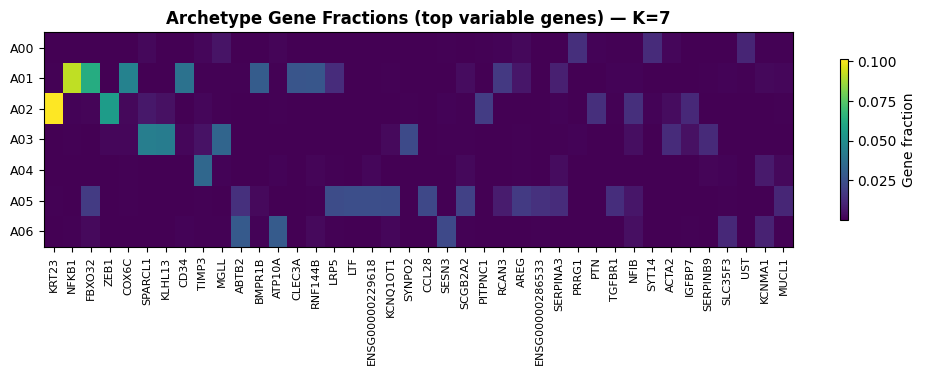

In [15]:
if best_runs:
    frac_df = best_run['fractions'].copy()
    frac_df.index = [f'A{idx:02d}' for idx in range(frac_df.shape[0])]

    # Show top variable genes for readability
    top_var_genes = frac_df.var(axis=0).sort_values(ascending=False).head(40).index
    mat = frac_df[top_var_genes]

    fig, ax = plt.subplots(figsize=(max(10, mat.shape[1] * 0.23), max(3.8, mat.shape[0] * 0.55)))
    im = ax.imshow(mat.values, aspect='auto', cmap='viridis')
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels(mat.index, fontsize=9)
    ax.set_title(f'Archetype Gene Fractions (top variable genes) — K={best_k}', fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.75, label='Gene fraction')
    fig.tight_layout()
    plt.show()



## Notes

- Processed file used for training: `data/bck44_scrna_hvg_counts.h5ad`.
- Sweep outputs: `outputs/bck44_scrna_nb_k_sweep/runs/`.
- Per-K summary table: `outputs/bck44_scrna_nb_k_sweep/k_sweep_summary.csv`.

